In [4]:
import kagglehub

In [5]:
from kagglehub import KaggleDatasetAdapter

In [6]:
kagglehub.dataset_download(  "undefinenull/million-song-dataset-spotify-lastfm")

100%|██████████| 639M/639M [00:06<00:00, 103MB/s] 

Extracting files...


'/root/.cache/kagglehub/datasets/undefinenull/million-song-dataset-spotify-lastfm/versions/1'

In [7]:
import os
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
data_path = Path("/root/.cache/kagglehub/datasets/undefinenull/million-song-dataset-spotify-lastfm/versions/1")
songs_data_path = data_path / 'Music Info.csv'
users_data_path = data_path / 'User Listening History.csv'


In [9]:
df_songs = pd.read_csv(songs_data_path)
df_users = pd.read_csv(users_data_path)

In [10]:
df_songs.head()

,track_id,name,artist,spotify_preview_url,spotify_id,tags,genre,year,duration_ms,danceability,...,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
0,TRIOREW128F424EAF0,Mr. Brightside,The Killers,https://p.scdn.co/mp3-preview/4d26180e6961fd46...,09ZQ5TmUG8TSL56n0knqrj,"rock, alternative, indie, alternative_rock, in...",NaN,2004,222200,0.355,...,1,-4.360,1,0.0746,0.001190,0.000000,0.0971,0.240,148.114,4
1,TRRIVDJ128F429B0E8,Wonderwall,Oasis,https://p.scdn.co/mp3-preview/d012e536916c927b...,06UfBBDISthj1ZJAtX4xjj,"rock, alternative, indie, pop, alternative_roc...",NaN,2006,258613,0.409,...,2,-4.373,1,0.0336,0.000807,0.000000,0.2070,0.651,174.426,4
2,TROUVHL128F426C441,Come as You Are,Nirvana,https://p.scdn.co/mp3-preview/a1c11bb1cb231031...,0keNu0t0tqsWtExGM3nT1D,"rock, alternative, alternative_rock, 90s, grunge",RnB,1991,218920,0.508,...,4,-5.783,0,0.0400,0.000175,0.000459,0.0878,0.543,120.012,4
3,TRUEIND128F93038C4,Take Me Out,Franz Ferdinand,https://p.scdn.co/mp3-preview/399c401370438be4...,0ancVQ9wEcHVd0RrGICTE4,"rock, alternative, indie, alternative_rock, in...",NaN,2004,237026,0.279,...,9,-8.851,1,0.0371,0.000389,0.000655,0.1330,0.490,104.560,4
4,TRLNZBD128F935E4D8,Creep,Radiohead,https://p.scdn.co/mp3-preview/e7eb60e9466bc3a2...,01QoK9DA7VTeTSE3MNzp4I,"rock, alternative, indie, alternative_rock, in...",RnB,2008,238640,0.515,...,7,-9.935,1,0.0369,0.010200,0.000141,0.1290,0.104,91.841,4


In [11]:
df_songs.shape

(50683, 21)

In [12]:
df_songs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50683 entries, 0 to 50682
Data columns (total 21 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   track_id             50683 non-null  object 
 1   name                 50683 non-null  object 
 2   artist               50683 non-null  object 
 3   spotify_preview_url  50683 non-null  object 
 4   spotify_id           50683 non-null  object 
 5   tags                 49556 non-null  object 
 6   genre                22348 non-null  object 
 7   year                 50683 non-null  int64  
 8   duration_ms          50683 non-null  int64  
 9   danceability         50683 non-null  float64
 10  energy               50683 non-null  float64
 11  key                  50683 non-null  int64  
 12  loudness             50683 non-null  float64
 13  mode                 50683 non-null  int64  
 14  speechiness          50683 non-null  float64
 15  acousticness         50683 non-null 

In [13]:
df_songs.drop(columns=['spotify_preview_url'],inplace=True)

In [14]:
df_songs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50683 entries, 0 to 50682
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   track_id          50683 non-null  object 
 1   name              50683 non-null  object 
 2   artist            50683 non-null  object 
 3   spotify_id        50683 non-null  object 
 4   tags              49556 non-null  object 
 5   genre             22348 non-null  object 
 6   year              50683 non-null  int64  
 7   duration_ms       50683 non-null  int64  
 8   danceability      50683 non-null  float64
 9   energy            50683 non-null  float64
 10  key               50683 non-null  int64  
 11  loudness          50683 non-null  float64
 12  mode              50683 non-null  int64  
 13  speechiness       50683 non-null  float64
 14  acousticness      50683 non-null  float64
 15  instrumentalness  50683 non-null  float64
 16  liveness          50683 non-null  float6

In [15]:
# check for the misinig values
df_songs.isna().sum()

,0
track_id,0
name,0
artist,0
spotify_id,0
tags,1127
genre,28335
year,0
duration_ms,0
danceability,0
energy,0


In [16]:
import missingno as msno

<Axes: >

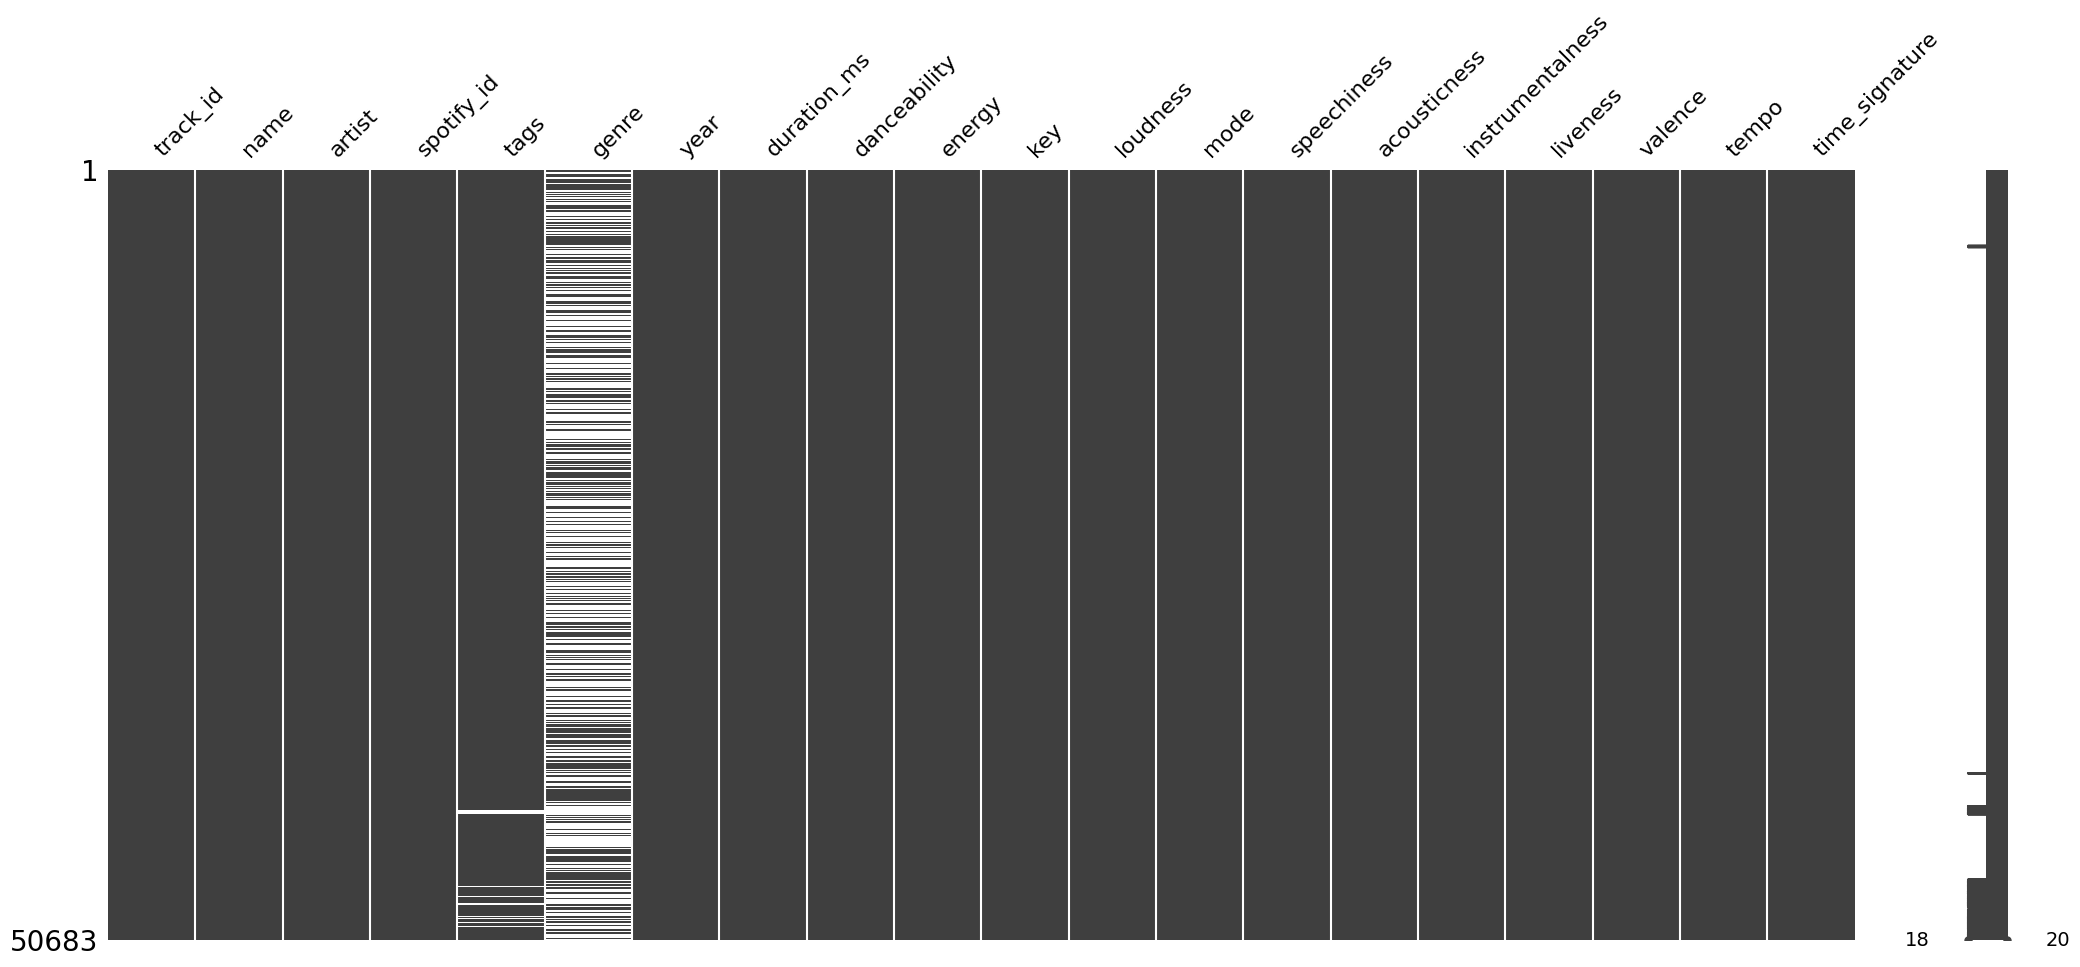

In [17]:
msno.matrix(df_songs)

In [18]:
# ratio  of missing values in the ata
(
    df_songs.isna()
    .mean()
    .sort_values(ascending=False)
    .head(2)
    .mul(100)
)

,0
genre,55.906320
tags,2.223625


In [19]:
#  check for the duplicates based on name of the song
(
    df_songs
    .assign(name=df_songs['name'].str.lower()) #assign new DataFrame with name to lowercase but better caleaning
    .duplicated(subset='name')
    .sum()
)

np.int64(815)

There are 815 rows duplicated in the name column

In [20]:
  # now rows taht are duplicated
(
    df_songs
    .loc[
        df_songs
        .assign(name=df_songs['name'].str.lower())
        .duplicated(subset='name',keep=False)
    ]
    .assign(name=df_songs['name'].str.lower())
    .sort_values('name')
)

,track_id,name,artist,spotify_id,tags,genre,year,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
34480,TRKKZMK128F4257579,3 am,Liv Kristine,1TgsnkiolcBhQssCR37JXx,"female_vocalists, power_metal, gothic_metal, g...",NaN,2005,302880,0.516,0.840,0,-6.038,0,0.0390,0.152000,0.005970,0.107,0.441,78.009,4
6588,TRGGALK12903CB68E5,3 am,Matchbox Twenty,5vYA1mW9g2Coh1HUFUSmlb,"rock, alternative, pop, alternative_rock, 90s,...",NaN,1996,225946,0.521,0.673,8,-8.685,1,0.0284,0.005730,0.000000,0.120,0.543,108.031,4
29795,TRLOXMF128F934BF04,3am,Matchbox Twenty,5vYA1mW9g2Coh1HUFUSmlb,"rock, alternative, 90s, piano, american, pop_rock",NaN,1996,225946,0.521,0.673,8,-8.685,1,0.0284,0.005730,0.000000,0.120,0.543,108.031,4
43800,TRPWOAS128E0781045,3am,Halsey,1OfLNb6dQ9dra1B58iT9Ex,pop_rock,NaN,2020,234858,0.385,0.871,0,-4.604,0,0.0795,0.009060,0.000000,0.579,0.538,189.760,4
15088,TRJRBRX128F4255789,4th of july,Soundgarden,237oH9rNUYpIBeHfAn3WJ0,"hard_rock, 90s, grunge",NaN,1994,308866,0.368,0.749,5,-5.523,0,0.0392,0.109000,0.000372,0.175,0.193,141.901,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34772,TRJFGYO128F4259743,you're the one that i want,Lo-Fang,1dEHQktvcM8vCCyI1x7yVB,"indie, male_vocalists, cover",NaN,2014,204706,0.445,0.309,11,-12.517,0,0.0404,0.643000,0.000369,0.224,0.153,119.754,4
32677,TRFZYLL128F146902A,you've really got a hold on me,Smokey Robinson and The Miracles,03AkIZeRvGpTvDF9vNJtdj,"soul, 60s, oldies",Rock,2012,179513,0.674,0.515,0,-6.895,1,0.0296,0.724000,0.000000,0.339,0.596,116.678,3
20976,TRUXHGS128F145E41A,you've really got a hold on me,The Miracles,01FtGX94CSvO5Zxs5B6AMM,"soul, 60s, oldies",NaN,1994,180266,0.679,0.406,0,-10.533,1,0.0312,0.755000,0.000000,0.412,0.511,117.940,3
27680,TRXWPMW12903CB42A0,zombies,Childish Gambino,73kAUSAht4YOR7xNPmNb2L,funk,NaN,2016,281813,0.653,0.411,0,-11.986,1,0.1270,0.503000,0.000969,0.067,0.468,160.055,4


here name can not be alone saying this is the redundancy. Two songs woth same name but different artist can be there.


In [21]:
(
    df_songs
    .loc[
        df_songs
        .duplicated(subset=['spotify_id','year','duration_ms'],keep=False)
    ]
    .sort_values(['spotify_id','year','duration_ms'])
)

,track_id,name,artist,spotify_id,tags,genre,year,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
15326,TRJNHPN128F92EF139,Adagio For Strings,Samuel Barber,00otCiz9kUb3Vg7LPKNCZG,"instrumental, classical, soundtrack, beautiful",NaN,2014,431412,0.140,0.0947,10,-18.599,0,0.0458,0.97800,0.478000,0.0735,0.0365,84.560,4
21570,TRLSRQD128F426CFF8,"Adagio for Strings, Op. 11",Samuel Barber,00otCiz9kUb3Vg7LPKNCZG,classical,NaN,2014,431412,0.140,0.0947,10,-18.599,0,0.0458,0.97800,0.478000,0.0735,0.0365,84.560,4
14861,TRLOZQZ128F92E8A3F,How Do You Want It,2Pac,02VsIBmSkhc7uHNyPViZR3,"rap, hip_hop",NaN,2011,289000,0.832,0.7850,8,-2.859,1,0.0930,0.11100,0.000007,0.0623,0.8120,92.468,4
14981,TRXHJQY128F42B5094,How Do U Want It,2Pac,02VsIBmSkhc7uHNyPViZR3,"rap, hip_hop, american",Rap,2011,289000,0.832,0.7850,8,-2.859,1,0.0930,0.11100,0.000007,0.0623,0.8120,92.468,4
37040,TRGCZFO128F92EE221,Je pense à toi,Amadou & Mariam,09jsAIZF9ThihIzdrw4KAS,"alternative, beautiful, french",NaN,2005,316880,0.680,0.3990,11,-11.585,0,0.0279,0.74900,0.001610,0.1580,0.8280,106.349,4
49162,TRZBNQU128F148C04F,Je Pense A Toi,Amadou & Mariam,09jsAIZF9ThihIzdrw4KAS,NaN,NaN,2005,316880,0.680,0.3990,11,-11.585,0,0.0279,0.74900,0.001610,0.1580,0.8280,106.349,4
13427,TRJQFIT128E0781CED,Too Much Too Young,The Specials,0ndKJL8gA4zLl317M7vndn,"punk, 80s, new_wave, reggae, ska",NaN,2012,116160,0.597,0.8390,2,-9.052,1,0.0471,0.44700,0.000134,0.3100,0.9650,156.058,4
46512,TRDTUTO128F422F138,Too Much Too Young (Live),The Specials,0ndKJL8gA4zLl317M7vndn,ska,NaN,2012,116160,0.597,0.8390,2,-9.052,1,0.0471,0.44700,0.000134,0.3100,0.9650,156.058,4
1684,TRRZUGN128F42A1EEE,There There,Radiohead,0thdzbW0cRKCx12VbBRB6T,"rock, electronic, alternative, indie, alternat...",Rock,2008,323600,0.614,0.6770,9,-8.317,0,0.0323,0.01930,0.518000,0.1080,0.7170,126.477,4
2983,TRXFHCL128F92E0989,"There, There",Radiohead,0thdzbW0cRKCx12VbBRB6T,"rock, electronic, alternative, indie, alternat...",NaN,2008,323600,0.614,0.6770,9,-8.317,0,0.0323,0.01930,0.518000,0.1080,0.7170,126.477,4


In [22]:
 df_songs.drop_duplicates(subset=['spotify_id','year','duration_ms'],inplace=True)

In [23]:
(
    df_songs
    .duplicated(subset=['spotify_id','year','duration_ms'])
    .sum()
)
# no duplicates left

np.int64(0)

In [24]:
df_songs.columns

Index(['track_id', 'name', 'artist', 'spotify_id', 'tags', 'genre', 'year',
       'duration_ms', 'danceability', 'energy', 'key', 'loudness', 'mode',
       'speechiness', 'acousticness', 'instrumentalness', 'liveness',
       'valence', 'tempo', 'time_signature'],
      dtype='object')

In [25]:
#  Catorical columns
categorical_columns = df_songs.select_dtypes(include="object").columns
categorical_columns

Index(['track_id', 'name', 'artist', 'spotify_id', 'tags', 'genre'], dtype='object')

In [26]:
def categorical_analysis(df,feature_names,k_artists=15):
  for feature in feature_names:
    print(f"Number of categories in column {feature} are ",df[feature].str.lower().nunique())
    if feature in ["artist","genere"]:
      print(df[feature].value_counts().head(k_artists))

      if feature == "genere":
        print(f"The unique categories in {feature} column ",df[feature].dropna().unique())
      print("#"*75)

In [28]:
categorical_analysis(df_songs,categorical_columns)

Number of categories in column track_id are  50674
Number of categories in column name are  49860
Number of categories in column artist are  8317
artist
The Rolling Stones    132
Radiohead             110
Autechre              105
Tom Waits             100
Bob Dylan              98
The Cure               94
Metallica              85
Johnny Cash            84
Nine Inch Nails        83
Sonic Youth            81
Iron Maiden            76
In Flames              76
Elliott Smith          76
Mogwai                 75
Boards of Canada       75
Name: count, dtype: int64
###########################################################################
Number of categories in column spotify_id are  50674
Number of categories in column tags are  20054
Number of categories in column genre are  15


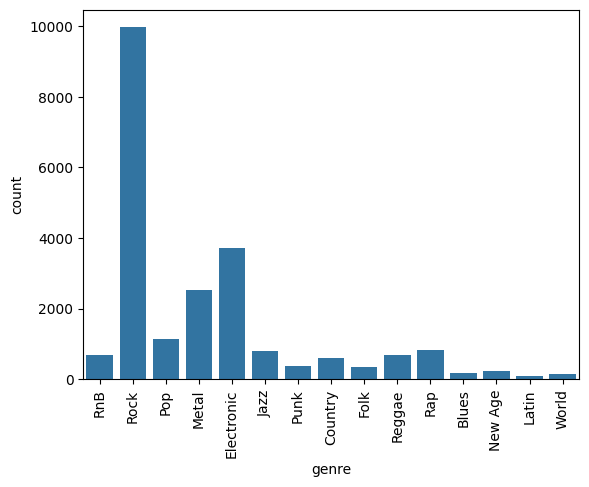

In [29]:
# Countplot of genre

sns.countplot(df_songs,x="genre")
plt.xticks(rotation=90)
plt.show()

In [31]:
#  genere group

genre_group = df_songs.groupby('genre')
genre_group[["genre",'tags']].sample(3)

,genre,tags
23216,Blues,"electronic, soundtrack, trip_hop"
44426,Blues,"classic_rock, british, blues, piano, 60s, blue..."
23896,Blues,"rock, classic_rock, blues, 60s, guitar, blues_..."
33366,Country,"female_vocalists, country"
29441,Country,"electronic, dance, house"
18461,Country,"rock, alternative_rock, hard_rock, progressive..."
6998,Electronic,"pop, female_vocalists, dance, 80s, love"
29693,Electronic,"electronic, house, techno"
3298,Electronic,"electronic, chillout, trip_hop, downtempo, lou..."
44613,Folk,"folk, singer_songwriter, beautiful, avant_garde"


In [36]:
all_tags = []

for tags in df_songs["tags"].dropna().str.replace(" ","").str.split(','):
  all_tags.extend(tags)

In [37]:
print(" Length of unique tags found ",len(set(all_tags)))

 Length of unique tags found  100


In [51]:
(
    df_songs
    .loc[:,"tags"]
    .dropna()
    .str.split(",")
    .explode()
    .str.strip()
)

,tags
0,rock
0,alternative
0,indie
0,alternative_rock
0,indie_rock
...,...
50680,metal
50680,metalcore
50680,post_hardcore
50682,rock


**Interger data based ds EDA now in the dataest**


In [53]:
interger_columns = df_songs.select_dtypes(include="int").columns
interger_columns

Index(['year', 'duration_ms', 'key', 'mode', 'time_signature'], dtype='object')

In [54]:
df_songs.info()

<class 'pandas.core.frame.DataFrame'>
Index: 50674 entries, 0 to 50682
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   track_id          50674 non-null  object 
 1   name              50674 non-null  object 
 2   artist            50674 non-null  object 
 3   spotify_id        50674 non-null  object 
 4   tags              49548 non-null  object 
 5   genre             22347 non-null  object 
 6   year              50674 non-null  int64  
 7   duration_ms       50674 non-null  int64  
 8   danceability      50674 non-null  float64
 9   energy            50674 non-null  float64
 10  key               50674 non-null  int64  
 11  loudness          50674 non-null  float64
 12  mode              50674 non-null  int64  
 13  speechiness       50674 non-null  float64
 14  acousticness      50674 non-null  float64
 15  instrumentalness  50674 non-null  float64
 16  liveness          50674 non-null  float64
 17

In [55]:
# now dataframe of these integer columns only
df_songs[interger_columns]

,year,duration_ms,key,mode,time_signature
0,2004,222200,1,1,4
1,2006,258613,2,1,4
2,1991,218920,4,0,4
3,2004,237026,9,1,4
4,2008,238640,7,1,4
...,...,...,...,...,...
50678,2008,273440,6,0,4
50679,2004,275133,0,1,4
50680,2014,254826,10,0,4
50681,2008,243293,4,0,4


# Integer Based Columns

### Key
**What it means:** The musical key in which the song is composed, represented as integers (e.g., $0 = \text{C}$, $1 = \text{C\#}$, $2 = \text{D}$, etc., up to 11).

*   **When value is small:** Represents keys like C or D, often associated with simplicity or familiarity.
*   **When value is large:** Represents keys like A# or B, which may sound brighter or more complex, depending on the context.

---

### Mode
**What it means:** Refers to the modality of the song, where $0 = \text{minor}$ (often associated with sadness or tension) and $1 = \text{major}$ (associated with happiness or resolution).

*   **When value is small:** Indicates the song is in a minor mode, creating a more somber or serious tone.
*   **When value is large:** Indicates the song is in a major mode, giving it a cheerful and uplifting feel.

---

### Time Signature
**What it means:** The number of beats in each bar of music, typically expressed as an integer (e.g., 4 for 4/4 time).

*   **When value is small:** Indicates fewer beats per measure (e.g., 3), which can create a waltz-like or less conventional rhythm.
*   **When value is large:** Indicates more beats per measure (e.g., 5 or 7), often leading to a more complex or experimental rhythmic structure.

> A value of **4** in the time signature typically means the song is in **4/4 time**, also known as "common time." This means there are **4 beats per measure**, and the quarter note gets one beat.
>
> Impact of a 4 Time Signature:

In [59]:
#  statistical summary

(
    df_songs
    .loc[:,interger_columns]
    .drop(columns=["duration_ms"])
    .assign(**{
        col:df_songs[col].astype("object")
        for col in interger_columns.drop("duration_ms")
    })
    .describe()
)

,year,key,mode,time_signature
count,50674,50674,50674,50674
unique,75,12,2,5
top,2007,9,1,4
freq,4221,5907,31979,44981


In [61]:
# range of data
(
    df_songs
    .loc[:,interger_columns]
    .assign(duration_minutes=df_songs["duration_ms"].div(1000).div(60))
    .drop(columns=["duration_ms"])
    .agg(["min","max"])
)

,year,key,mode,time_signature,duration_minutes
min,1900,0,0,0,0.023983
max,2022,11,1,5,63.606217


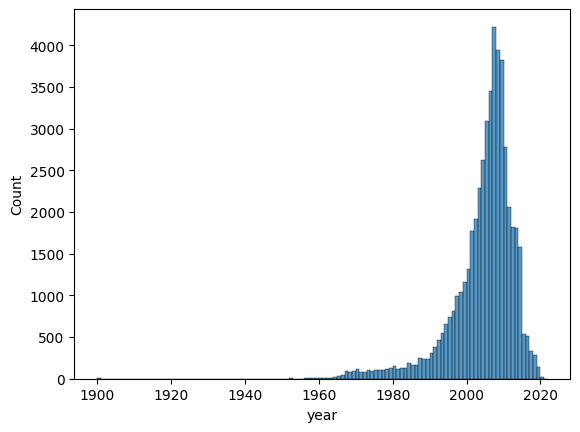

In [62]:
sns.histplot(df_songs,x="year",bins=df_songs["year"].max() - df_songs["year"].min())
plt.show()


In [70]:
df_songs.groupby("year")["year  "].value_counts().sort_values(ascending=False)

,count
year,
2007,4221
2008,3947
2009,3827
2006,3453
2005,3085
...,...
1954,2
1950,1
1951,1


In [75]:
# most songs from which year
(
    df_songs
    .loc[:,"year"]
    .value_counts()
    .head(5)
    .sort_index()
)

,count
year,
2005,3085
2006,3453
2007,4221
2008,3947
2009,3827
